# PHY 5103 — Homework 2 computational checks

Problems: CH2 : **1, **

Handwritten derivations are the submission. this is symbolic computational (residuals/independent checks, limiting case etgc)


In [3]:
#setup
import os
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.animation as animation

#from scipy.integrate import solve_ivp
from IPython.display import display, Image

sp.init_printing()
plt.style.use('dark_background')

os.makedirs('graphs', exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f'graphs/{name}', dpi=300, bbox_inches='tight')


# Problem 1

'f ='

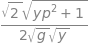

"df/dy' ="

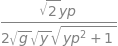

'Beltrami invariant ='

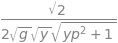

'Beltrami check ='

'dx/dphi ='

'dy/dphi ='

'dy/dx ='

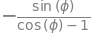

"y(1 + y'^2) - 2a ="

"(y + z)(1 + y'^2) - 2a ="

In [8]:
#symbols
y, yp, g, a, phi, z = sp.symbols(
    'y yp g a phi z',
    positive=True
)
#validate beltrami invariant
f = sp.sqrt((1 + yp**2) / (2*g*y))

df_dyp = sp.diff(f, yp)

beltrami = sp.simplify(f - yp*df_dyp)

display("f =", f)
display("df/dy' =", df_dyp)
display("Beltrami invariant =", beltrami)

expected_beltrami = 1 / sp.sqrt(2*g*y*(1 + yp**2))

display(
    "Beltrami check =",
    sp.simplify(beltrami - expected_beltrami)
)

#validate cycloid against first intg.
x_phi = a*(phi - sp.sin(phi))
y_phi = a*(1 - sp.cos(phi))

dx_dphi = sp.diff(x_phi, phi)
dy_dphi = sp.diff(y_phi, phi)

yp_param = sp.simplify(dy_dphi / dx_dphi)

display("dx/dphi =", dx_dphi)
display("dy/dphi =", dy_dphi)
display("dy/dx =", sp.trigsimp(yp_param))

first_integral_check = sp.trigsimp(
    y_phi*(1 + yp_param**2) - 2*a
)

display(
    "y(1 + y'^2) - 2a =",
    sp.simplify(first_integral_check)
)

#validate shifted cyc. for v0!-0
y_shifted = a*(1 - sp.cos(phi)) - z

dy_shifted_dphi = sp.diff(y_shifted, phi)

yp_shifted = sp.simplify(
    dy_shifted_dphi / dx_dphi
)

shifted_check = sp.trigsimp(
    (y_shifted + z)*(1 + yp_shifted**2) - 2*a
)

display(
    "(y + z)(1 + y'^2) - 2a =",
    sp.simplify(shifted_check)
)

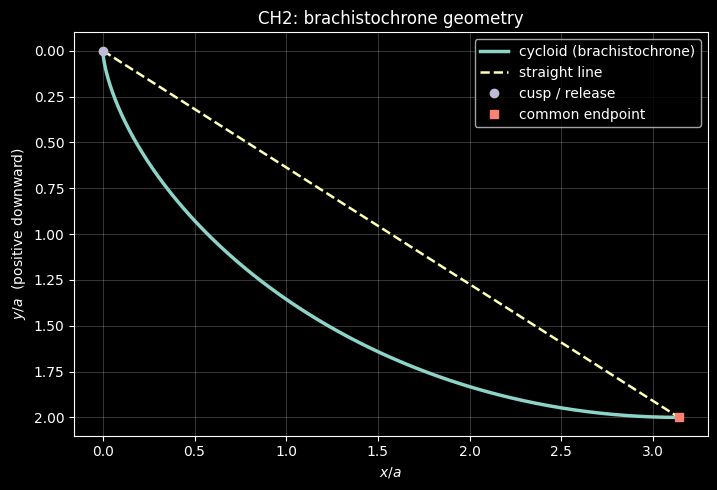

endpoint: x/a = 3.141593, y/a = 2.000000
cycloid parametrization: x=a(phi-sin(phi)), y=a(1-cos(phi))


In [10]:
#static brachistochrone geometry v straight line
#+y is postitive and down (matchin goldstein)
a = 1.0
g = 9.81
phi_f = np.pi

phi = np.linspace(0.0, phi_f, 700)
x_cyc = a * (phi - np.sin(phi))
y_cyc = a * (1.0 - np.cos(phi))

x_f = x_cyc[-1]
y_f = y_cyc[-1]

#straight path joining endpoints
lam = np.linspace(0.0, 1.0, 300)
x_line = lam * x_f
y_line = lam * y_f

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_cyc, y_cyc, lw=2.5, label='cycloid (brachistochrone)')
ax.plot(x_line, y_line, '--', lw=1.8, label='straight line')
ax.plot([0], [0], 'o', ms=6, label='cusp / release')
ax.plot([x_f], [y_f], 's', ms=6, label='common endpoint')

ax.set_xlabel(r'$x/a$')
ax.set_ylabel(r'$y/a$  (positive downward)')
ax.set_title('CH2: brachistochrone geometry')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_aspect('equal', adjustable='box')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('graphs/ch2_brachistochrone_paths.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'endpoint: x/a = {x_f/a:.6f}, y/a = {y_f/a:.6f}')
print('cycloid parametrization: x=a(phi-sin(phi)), y=a(1-cos(phi))')



T_cycloid = 1.003033 s
T_straight = 1.189043 s
cycloid advantage = 0.186010 s


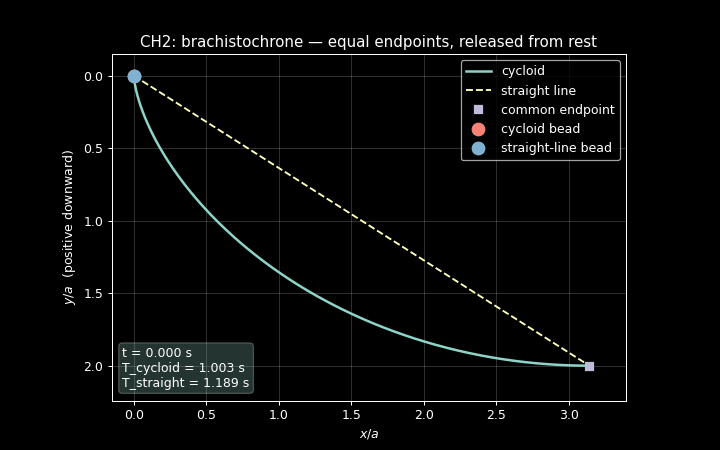

In [12]:
#gif of bead on cycloid v. bead on straight incline

#common endpoints
x_f = a * (phi_f - np.sin(phi_f))
y_f = a * (1.0 - np.cos(phi_f))

#ref paths
phi_path = np.linspace(0.0, phi_f, 700)
x_path = a * (phi_path - np.sin(phi_path))
y_path = a * (1.0 - np.cos(phi_path))

lam = np.linspace(0.0, 1.0, 300)
x_line_path = lam * x_f
y_line_path = lam * y_f

#exact cycloid time from calc:
#ds = 2a sin(phi/2)dphi
#v  = 2 sqrt(a g) sin(phi/2)
#therefore dt = sqrt(a/g)dphi
T_cyc = np.sqrt(a / g) * phi_f

#straight frictionaless incline: a_parallel = g sin(alpha) = g*y_f/L
L = np.hypot(x_f, y_f)
a_line = g * y_f / L
T_line = np.sqrt(2.0 * L / a_line)

#make it 7 seconds real time ani
fps = 30
duration_s = 7
frames = fps * duration_s

#sim runs until slower bead reaches endpoint
t_sim = np.linspace(0.0, T_line, frames)

#cycloid (phi grows linearly w/ act time)
phi_t = np.clip(t_sim / np.sqrt(a / g), 0.0, phi_f)
x_c = a * (phi_t - np.sin(phi_t))
y_c = a * (1.0 - np.cos(phi_t))

#straight line: s = (1/2) a_parallel t^2
s_line = np.minimum(0.5 * a_line * t_sim**2, L)
frac = s_line / L
x_s = frac * x_f
y_s = frac * y_f

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_path, y_path, lw=2.0, label='cycloid')
ax.plot(x_line_path, y_line_path, '--', lw=1.5, label='straight line')
ax.plot([x_f], [y_f], 's', ms=6, label='common endpoint')

bead_c, = ax.plot([], [], 'o', ms=10, label='cycloid bead')
bead_s, = ax.plot([], [], 'o', ms=10, label='straight-line bead')

time_text = ax.text(
    0.02, 0.04, '', transform=ax.transAxes,
    bbox=dict(boxstyle='round', alpha=0.25)
)

ax.set_xlim(-0.15, 1.08 * x_f)
ax.set_ylim(-0.15, 1.12 * y_f)
ax.invert_yaxis()
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$x/a$')
ax.set_ylabel(r'$y/a$  (positive downward)')
ax.set_title('CH2: brachistochrone — equal endpoints, released from rest')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

def update(i):
    bead_c.set_data([x_c[i]], [y_c[i]])
    bead_s.set_data([x_s[i]], [y_s[i]])

    time_text.set_text(
        f't = {t_sim[i]:.3f} s\n'
        f'T_cycloid = {T_cyc:.3f} s\n'
        f'T_straight = {T_line:.3f} s'
    )
    return bead_c, bead_s, time_text

ani = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=1000 / fps,
    blit=False
)

gif_name = 'graphs/ch2_brachistochrone_7s.gif'
ani.save(gif_name, writer='pillow', fps=fps, dpi=90)
plt.close(fig)

print(f'T_cycloid = {T_cyc:.6f} s')
print(f'T_straight = {T_line:.6f} s')
print(f'cycloid advantage = {T_line - T_cyc:.6f} s')
display(Image(filename=gif_name))



## outputs

All static figures and GIFs are written to `graphs/` when the notebook is run
- will sync to my git
